In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- DATA SETUP ---
url = "https://raw.githubusercontent.com/bnokoro/Data-Science/master/countries%20of%20the%20world.csv"
df = pd.read_csv(url)

# Cleaning: Fix decimal commas and strip strings
cols_to_fix = ['Infant mortality (per 1000 births)', 'Birthrate', 'Phones (per 1000)', 'Service', 'Area (sq. mi.)', 'Population']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)
df['Region'] = df['Region'].str.strip()

# ==========================================
# TASK 1 (NumPy): Percentiles
# English: Use NumPy to calculate the 10th percentile of 'Infant mortality (per 1000 births)'.
# Հայերեն: Օգտագործեք NumPy-ը՝ հաշվելու 'Infant mortality (per 1000 births)'-ի 10-րդ պերցենտիլը:
# ------------------------------------------

# ==========================================
# TASK 2 (NumPy): Conditional Labeling
# English: Create a new column 'Birth_Category' using np.where. 
# If 'Birthrate' > 30, label it 'High', otherwise 'Normal'.
# Հայերեն: Ստեղծեք նոր 'Birth_Category' սյունակ՝ օգտագործելով np.where: 
# Եթե 'Birthrate' > 30, նշեք 'High', հակառակ դեպքում՝ 'Normal':
# ------------------------------------------

# ==========================================
# TASK 3 (Pandas): Multi-Condition Filtering
# English: Filter for countries in 'SUB-SAHARAN AFRICA' with 'Phones (per 1000)' > 100.
# Հայերեն: Զտեք այն երկրները 'SUB-SAHARAN AFRICA' տարածաշրջանում, որոնք ունեն 100-ից ավել 'Phones (per 1000)':
# ------------------------------------------

# ==========================================
# TASK 4 (Pandas): Grouped Aggregation
# English: Group by 'Region' and calculate the mean 'Service' (economic sector) for each region.
# Հայերեն: Խմբավորեք ըստ 'Region'-ի և հաշվեք յուրաքանչյուր տարածաշրջանի 'Service' (տնտեսական ոլորտ) միջինը:
# ------------------------------------------

# ==========================================
# TASK 5 (Matplotlib): Visualization & Annotation
# English: Create a scatter plot of 'Area (sq. mi.)' vs 'Population'.
# 1. Use log scales for both axes (plt.xscale('log'), plt.yscale('log')).
# 2. Color points by 'GDP ($ per capita)'.
# 3. Use plt.annotate to label 'China'.
# Հայերեն: Ստեղծեք 'Area (sq. mi.)'-ի և 'Population'-ի scatter plot:
# 1. Օգտագործեք լոգարիթմական սանդղակներ երկու առանցքների համար:
# 2. Գունավորեք կետերը ըստ 'GDP ($ per capita)'-ի:
# 3. Օգտագործեք plt.annotate՝ «China»-ն պիտակավորելու համար:
# ------------------------------------------

The 10th percentile for Infant Mortality is: 4.77

First 5 rows with Birth_Category:
          Country  Birthrate Birth_Category
0     Afghanistan      46.60           High
1         Albania      15.11         Normal
2         Algeria      17.14         Normal
3  American Samoa      22.46         Normal
4         Andorra       8.71         Normal

Number of Sub-Saharan countries with > 100 phones: 6

Mean Service Sector by Region:
Region
NORTHERN AMERICA        0.787000
WESTERN EUROPE          0.714625
BALTICS                 0.661667
LATIN AMER. & CARIB     0.650721
OCEANIA                 0.608938
EASTERN EUROPE          0.598667
NEAR EAST               0.530000
ASIA (EX. NEAR EAST)    0.520107
C.W. OF IND. STATES     0.480167
SUB-SAHARAN AFRICA      0.449755
NORTHERN AFRICA         0.432000
Name: Service, dtype: float64


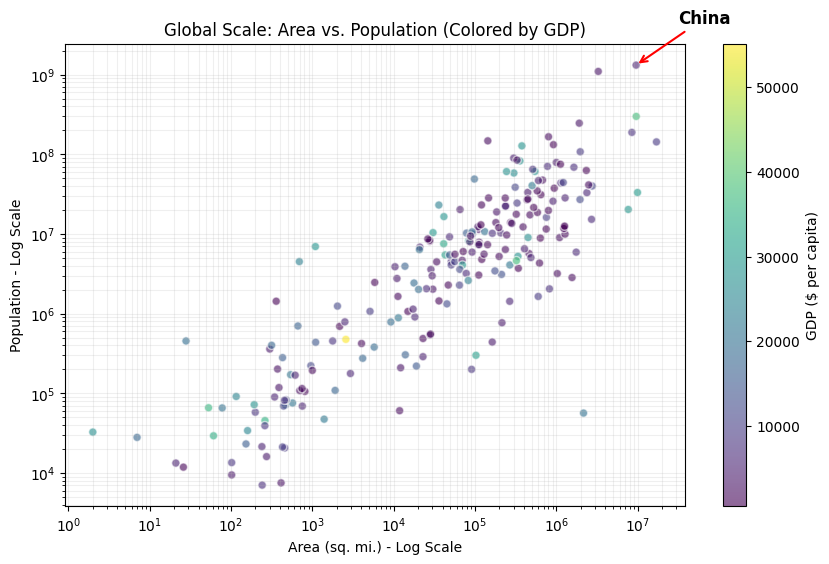

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- DATA SETUP (Provided in prompt) ---
url = "https://raw.githubusercontent.com/bnokoro/Data-Science/master/countries%20of%20the%20world.csv"
df = pd.read_csv(url)

# Cleaning: Fix decimal commas and strip strings
cols_to_fix = ['Infant mortality (per 1000 births)', 'Birthrate', 'Phones (per 1000)', 
               'Service', 'Area (sq. mi.)', 'Population', 'GDP ($ per capita)'] # Added GDP for Task 5
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

df['Region'] = df['Region'].str.strip()
df['Country'] = df['Country'].str.strip() # Crucial for Task 5 matching

# ==========================================
# TASK 1 (NumPy): Percentiles
# ------------------------------------------
# We use np.nanpercentile to ignore any missing (NaN) values in the column
infant_10th = np.nanpercentile(df['Infant mortality (per 1000 births)'], 10)

print(f"The 10th percentile for Infant Mortality is: {infant_10th:.2f}")

# ==========================================
# TASK 2 (NumPy): Conditional Labeling
# ------------------------------------------
df['Birth_Category'] = np.where(df['Birthrate'] > 30, 'High', 'Normal')

print("\nFirst 5 rows with Birth_Category:")
print(df[['Country', 'Birthrate', 'Birth_Category']].head())

# ==========================================
# TASK 3 (Pandas): Multi-Condition Filtering
# ------------------------------------------
# Use () to separate conditions and & for logical AND
africa_phones = df[(df['Region'] == 'SUB-SAHARAN AFRICA') & (df['Phones (per 1000)'] > 100)]

print(f"\nNumber of Sub-Saharan countries with > 100 phones: {len(africa_phones)}")

# ==========================================
# TASK 4 (Pandas): Grouped Aggregation
# ------------------------------------------
service_mean = df.groupby('Region')['Service'].mean().sort_values(ascending=False)

print("\nMean Service Sector by Region:")
print(service_mean)

# ==========================================
# TASK 5 (Matplotlib): Visualization & Annotation
# ------------------------------------------
plt.figure(figsize=(10, 6))

# 1. Create the scatter plot
# We use a colormap (cmap) to visualize GDP wealth
scatter = plt.scatter(df['Area (sq. mi.)'], df['Population'], 
                     c=df['GDP ($ per capita)'], cmap='viridis', 
                     alpha=0.6, edgecolors='white')

# 2. Set Log Scales
plt.xscale('log')
plt.yscale('log')

# 3. Add Labels and Titles
plt.xlabel('Area (sq. mi.) - Log Scale')
plt.ylabel('Population - Log Scale')
plt.title('Global Scale: Area vs. Population (Colored by GDP)')
plt.colorbar(scatter, label='GDP ($ per capita)')

# 4. Annotation for China
# We locate China's coordinates
china_data = df[df['Country'] == 'China']

if not china_data.empty:
    china_x = china_data['Area (sq. mi.)'].values[0]
    china_y = china_data['Population'].values[0]
    
    plt.annotate('China', 
                 xy=(china_x, china_y),          # Point to annotate
                 xytext=(30, 30),                # Text position offset
                 textcoords='offset points', 
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                 fontsize=12, fontweight='bold')

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()